# **Supermarket Sales Performance Analysis**

## **Business Objective**
This project aims to analyze supermarket transaction data to identify:
1. Revenue drivers;
2. Customer behavior patterns;
3. Branch performance differences;
4. Payment preferences.

## **Business Questions**
1. Which product line contributes the most to revenue?
2. How does branch performance differ?
3. How does membership affect spending?
4. What payment methods dominate per category?
5. How do weekday and weekend sales differ?

# **Data Overview**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler # optional
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [22]:
df = pd.read_csv('supermarket_sales.csv')
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1


# Data Exploration

In [23]:
# --- Basic Information ---
print("\n--- 1.1 Basic Dataset Information ---")

print(f"\n Dataset Shape: {df.shape}")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

print("\n First 10 Rows:")
print(df.head(10))

print("\n Last 5 Rows:")
print(df.tail(5))

print("\n Random Sample (5 rows):")
print(df.sample(5))

print("\n Data Types and Info:")
df.info()

print("\n Statistical Summary:")
print(df.describe())

print("\n Column Names:")
print(list(df.columns))


--- 1.1 Basic Dataset Information ---

 Dataset Shape: (1000, 17)
   Rows: 1000
   Columns: 17

 First 10 Rows:
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   
5  699-14-3026      C  Naypyitaw        Normal    Male   
6  355-53-5943      A     Yangon        Member  Female   
7  315-22-5665      C  Naypyitaw        Normal  Female   
8  665-32-9167      A     Yangon        Member  Female   
9  692-92-5582      B   Mandalay        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2    

In [24]:
# --- Check for Issues ---
print("\n--- 1.2 Data Quality Check ---")

print("\n Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✓ No missing values!")
else:
    print(missing[missing > 0])

print("\n Duplicates:")
duplicates = df.duplicated().sum()
print(f"   Duplicate rows: {duplicates}")

print("\n Unique Values per Column:")
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"   {col}: {unique_count} unique values")



--- 1.2 Data Quality Check ---

 Missing Values:
   ✓ No missing values!

 Duplicates:
   Duplicate rows: 0

 Unique Values per Column:
   Invoice ID: 1000 unique values
   Branch: 3 unique values
   City: 3 unique values
   Customer type: 2 unique values
   Gender: 2 unique values
   Product line: 6 unique values
   Unit price: 943 unique values
   Quantity: 10 unique values
   Tax 5%: 990 unique values
   Total: 990 unique values
   Date: 89 unique values
   Time: 506 unique values
   Payment: 3 unique values
   cogs: 990 unique values
   gross margin percentage: 1 unique values
   gross income: 990 unique values
   Rating: 61 unique values


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [26]:
#Mengubah tipe data pada kolom Date menjadi datetime
df['Date'] = pd.to_datetime(df['Date'])
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

In [27]:
#Mengubah tipe data di kolom Time menjadi datetime
df['Time'] = df['Time'].astype(str)
df['Time'] = pd.to_datetime(df['Time'], format='mixed').dt.time
type(df['Time'].iloc[0])

datetime.time

In [28]:
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,2019-01-29,13:46:00,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,2019-03-02,17:16:00,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2019-02-09,13:22:00,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2019-02-22,15:33:00,Cash,65.82,4.761905,3.2910,4.1


#🧹 **Data Quality Assessment**

Before proceeding to analysis, a data quality check was conducted to ensure the dataset was reliable and ready for exploration.

Key Findings:

No Missing Values: All 1,000 transactions contain complete information across all columns.

No Duplicate Records: Each transaction is uniquely identified by Invoice ID, ensuring data integrity.

Appropriate Data Types: Numerical, categorical, and datetime columns were properly formatted, enabling accurate aggregation, filtering, and time-based analysis.

Conclusion:

The dataset is clean, consistent, and analysis-ready, requiring no additional preprocessing such as imputation or duplicate removal.

# **Exploratory Data Analysis**

# **Product Revenue Contribution Analysis**

> **Which product line contributes the most to total revenue?**

In [29]:
# Aggregate total revenue per product line
product_revenue = (
    df.groupby('Product line')['Total']
    .sum()
    .sort_values(ascending=False)
)

product_revenue

,Total
Product line,
Food and beverages,56144.8440
Sports and travel,55122.8265
Electronic accessories,54337.5315
Fashion accessories,54305.8950
Home and lifestyle,53861.9130
Health and beauty,49193.7390


In [30]:
top_category = product_revenue.idxmax()
top_value = product_revenue.max()

print(f"Top Revenue Category: {top_category}")
print(f"Total Revenue: ${top_value:,.2f}")

Top Revenue Category: Food and beverages
Total Revenue: $56,144.84


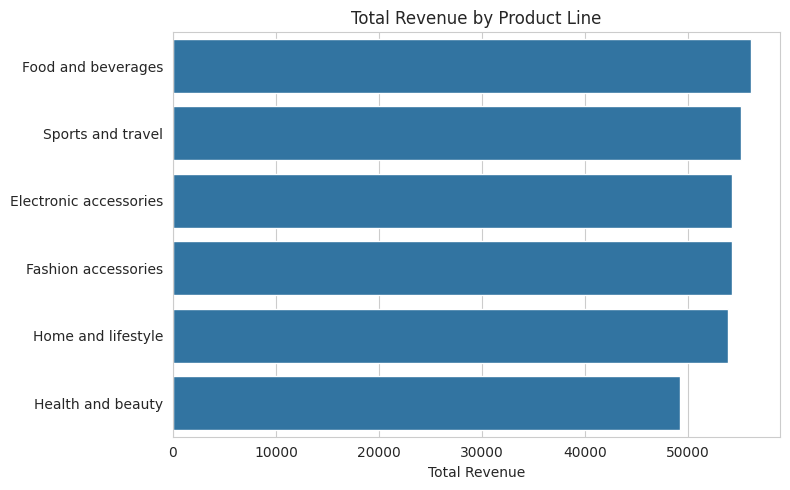

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index supaya bisa dipakai di seaborn
product_revenue_df = product_revenue.reset_index()
product_revenue_df.columns = ['Product Line', 'Total Revenue']

plt.figure(figsize=(8,5))
sns.barplot(
    data=product_revenue_df,
    x='Total Revenue',
    y='Product Line'
)

plt.title('Total Revenue by Product Line')
plt.xlabel('Total Revenue')
plt.ylabel('')
plt.tight_layout()
plt.show()

> 📌 **Insight**

Although Food & Beverages generates the highest total revenue, the gap between categories is relatively small. Revenue distribution across product lines appears balanced, with no single category overwhelmingly dominating sales performance.

This indicates that the supermarket does not rely heavily on one product segment, reducing revenue concentration risk and suggesting a diversified revenue structure.

> 💡 **Strategic Interpretation**

Food & Beverages functions as a reliable revenue backbone, driven by high-frequency purchases.

Categories such as Sports & Travel and Electronic Accessories also contribute significantly, indicating strong cross-category demand.

The balanced revenue spread suggests stable operational performance and lower vulnerability to category-specific downturns.

> 🎯 **Business Recommendation**

Maintain Food & Beverages as a traffic-driving category.

Implement cross-selling strategies to increase basket size across complementary categories.

Monitor category-level growth trends rather than focusing solely on the top-performing product line.

# **Branch Performance Analysis**

> **How does branch performance differ?**

In [32]:
# Total revenue per branch
branch_revenue = (
    df.groupby('Branch')['Total']
    .sum()
    .sort_values(ascending=False)
)

branch_revenue

,Total
Branch,
C,110568.7065
A,106200.3705
B,106197.6720


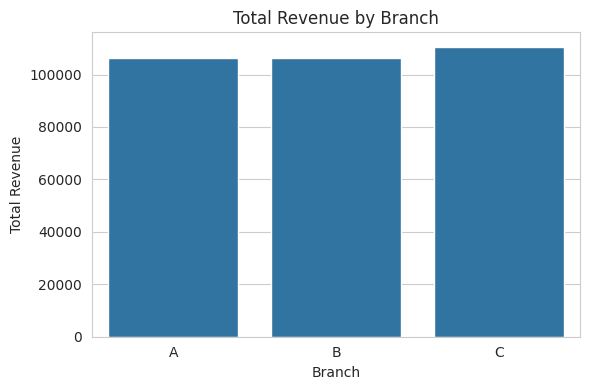

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

branch_revenue_df = branch_revenue.reset_index()
branch_revenue_df.columns = ['Branch', 'Total Revenue']

# SORT BERDASARKAN NAMA BRANCH
branch_revenue_df = branch_revenue_df.sort_values('Branch')

plt.figure(figsize=(6,4))
sns.barplot(data=branch_revenue_df, x='Branch', y='Total Revenue')

plt.title('Total Revenue by Branch')
plt.tight_layout()
plt.show()

> 📌 **Insight**

Branch C generates the highest total revenue; however, the performance gap between branches is relatively small. Revenue across Branch A, B, and C appears balanced, with no branch significantly underperforming.

This suggests consistent operational performance and relatively uniform customer demand across locations.

> 💡 **Strategic Interpretation**

Branch C holds a slight competitive edge, potentially due to location advantages or customer traffic.

The narrow revenue gap indicates stable distribution of sales performance.

No branch is overly dependent on a specific revenue stream.

> 🎯 **Business Recommendation**

Conduct deeper analysis on Branch C to identify replicable best practices.

Implement localized promotional strategies rather than uniform campaigns.

Monitor category performance per branch to identify micro-opportunities for growth.

# **Membership Impact on Customer Spending**

> **How does membership affect spending?**

In [34]:
membership_analysis = (
    df.groupby('Customer type')['Total']
    .agg(['sum','mean','count'])
)

membership_analysis

,sum,mean,count
Customer type,,,
Member,164223.444,327.791305,501
Normal,158743.305,318.122856,499


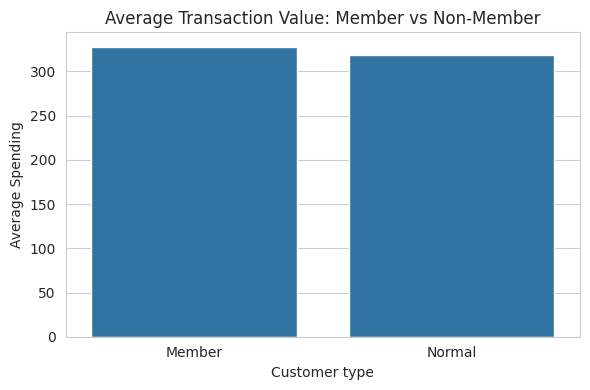

In [35]:
membership_df = membership_analysis.reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=membership_df, x='Customer type', y='mean')
plt.title('Average Transaction Value: Member vs Non-Member')
plt.ylabel('Average Spending')
plt.tight_layout()
plt.show()

> 📌 **Insight**

Members generate a slightly higher average transaction value compared to Non-Members. However, the spending gap between the two groups is relatively narrow, indicating that while the membership program has a positive impact, its influence on basket size remains limited.

> 💡 **Strategic Interpretation**

The near-balanced spending behavior suggests that the current membership value proposition may not be strong enough to significantly differentiate purchasing behavior.

Membership penetration appears stable, but incremental spending uplift per member is modest.

> 🎯 **Business Recommendation**

Strengthen exclusive member incentives (e.g., tiered rewards, personalized promotions).

Analyze high-value member segments to identify behavioral patterns that can be replicated.

Shift focus from acquisition to increasing lifetime value (LTV) per member.

# **Payment Behaviour Analysis**

> **What payment methods dominate per category?**

In [36]:
payment_category = (
    pd.crosstab(df['Product line'], df['Payment'], normalize='index') * 100
)

payment_category

Payment,Cash,Credit card,Ewallet
Product line,,,
Electronic accessories,41.764706,27.058824,31.176471
Fashion accessories,32.022472,31.460674,36.516854
Food and beverages,32.758621,35.057471,32.183908
Health and beauty,32.236842,32.894737,34.868421
Home and lifestyle,31.875000,28.125000,40.000000
Sports and travel,35.542169,31.927711,32.530120


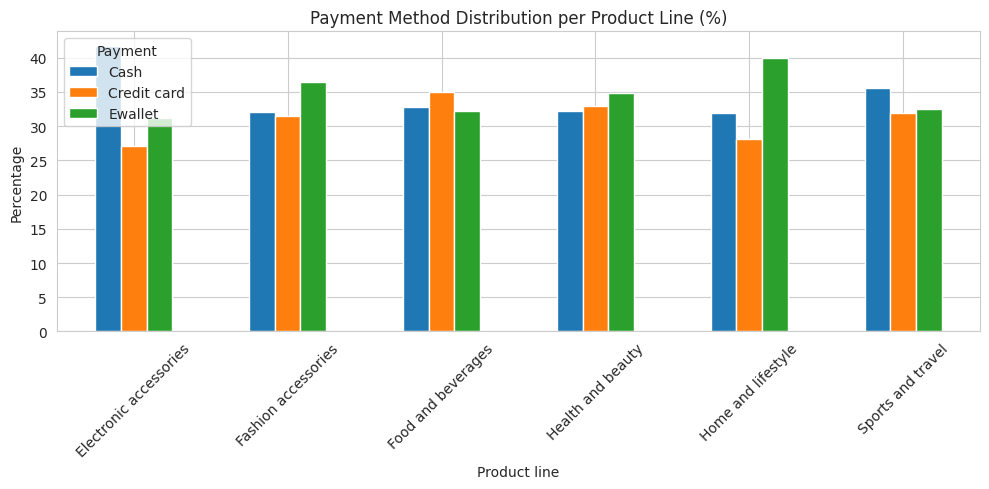

In [37]:
payment_category.plot(kind='bar', figsize=(10,5))
plt.title('Payment Method Distribution per Product Line (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> 📌 **Insight**

Payment preferences vary meaningfully across product categories, reflecting distinct customer purchasing behavior.

E-wallet dominates lifestyle-oriented categories, particularly Home & Lifestyle, indicating strong digital payment adoption in discretionary purchases.

Cash remains relatively strong in Electronic Accessories and Sports & Travel, suggesting customers may prefer direct or tangible payment methods for higher-value or functional products.

Credit card usage appears relatively balanced across categories, slightly leading in Food & Beverages, reflecting flexible payment behavior in daily-consumption transactions.

No single payment method overwhelmingly dominates across all product lines, indicating a diversified and stable payment ecosystem within the supermarket.

> 💡 **Strategic Interpretation**

Digital payment adoption is stronger in lifestyle-driven segments, suggesting a more digitally engaged customer base within these categories.

Cash persistence in functional or higher-ticket categories may indicate behavioral trust patterns or transaction security perception.

The balanced distribution across payment channels reduces dependency on a single payment method and enhances operational resilience.

> 🎯 **Business Recommendation**

Implement category-specific payment promotions rather than uniform discount campaigns.

Leverage strong e-wallet adoption in lifestyle categories through targeted cashback partnerships.

Introduce digital payment incentives in cash-dominant categories to gradually shift behavior.

Use diversified payment behavior as a strategic advantage when negotiating with payment partners or designing promotional bundles.

# **Weekday vs Weekend Sales Performance**

> **How do weekday and weekend sales differ?**

In [38]:
# Ensure Date column is datetime
df['Date'] = pd.to_datetime(df['Date'])

df['Day_of_Week'] = df['Date'].dt.dayofweek
df['Is_Weekend'] = df['Day_of_Week'].isin([5,6])

weekday_weekend = (
    df.groupby('Is_Weekend')['Total']
    .agg(['sum','mean','count'])
)

weekday_weekend

,sum,mean,count
Is_Weekend,,,
False,222388.047,316.341461,703
True,100578.702,338.648828,297


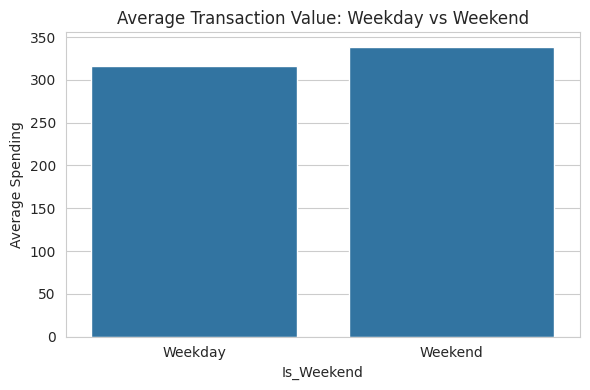

In [39]:
weekday_weekend_df = weekday_weekend.reset_index()
weekday_weekend_df['Is_Weekend'] = weekday_weekend_df['Is_Weekend'].map({False:'Weekday', True:'Weekend'})

plt.figure(figsize=(6,4))
sns.barplot(data=weekday_weekend_df, x='Is_Weekend', y='mean')
plt.title('Average Transaction Value: Weekday vs Weekend')
plt.ylabel('Average Spending')
plt.tight_layout()
plt.show()

> 📌 **Insight**

Weekend transactions generate higher average spending per visit compared to weekdays.

Although weekdays typically contribute higher total revenue due to greater transaction volume, customers tend to spend more per transaction during weekends.

The difference in basket size suggests distinct purchasing behavior between routine weekday shopping and more deliberate weekend purchasing.

> 💡 **Strategic Interpretation**

Weekend shopping behavior appears to be more planned and potentially bulk-oriented, leading to higher basket value per visit.

Weekday transactions are likely driven by convenience-based or necessity-driven purchases, resulting in higher volume but lower per-transaction spending.

The temporal variation in spending patterns indicates an opportunity to differentiate promotional strategies based on day type.

> 🎯 **Business Recommendation**

Implement premium bundling and upselling strategies during weekends to maximize higher basket size behavior.

Use weekday promotions focused on volume-driven incentives such as flash discounts or loyalty point multipliers.

Align staffing, inventory planning, and promotional intensity with distinct weekday and weekend purchasing patterns to optimize operational efficiency and revenue performance.

# **Conclusion**

1. The analysis reveals that Food & Beverages is the highest revenue contributor, although revenue distribution across product lines remains relatively balanced, indicating diversified category performance.

2. Branch performance is consistent across locations, with only marginal differences in total revenue, suggesting stable operational management and uniform demand distribution.

3. Membership contributes to slightly higher average transaction value, but the spending gap remains modest, indicating room to strengthen the membership value proposition.

4. Payment behavior varies across categories, with stronger digital adoption in lifestyle segments and continued relevance of cash in functional or higher-value purchases.

5. Weekend transactions generate higher average spending per visit, while weekdays drive higher transaction volume, reflecting different purchasing patterns based on time.